# **Product Recognition of Books**

## Image Processing and Computer Vision - Assignment Module \#1


Contacts:

- Prof. Giuseppe Lisanti -> giuseppe.lisanti@unibo.it
- Prof. Samuele Salti -> samuele.salti@unibo.it
- Alex Costanzino -> alex.costanzino@unibo.it
- Francesco Ballerini -> francesco.ballerini4@unibo.it

Computer vision-based object detection techniques can be applied in library or bookstore settings to build a system that identifies books on shelves.

Such a system could assist in:
* Helping visually impaired users locate books by title/author;
* Automating inventory management (e.g., detecting misplaced or out-of-stock books);
* Enabling faster book retrieval by recognizing spine text or cover designs.

## Task
Develop a computer vision system that, given a reference image for each book, is able to identify such book from one picture of a shelf.

<figure>
<a href="https://ibb.co/pvLVjbM5"><img src="https://i.ibb.co/svVx9bNz/example.png" alt="example" border="0"></a>
</figure>

For each type of product displayed on the shelf, the system should compute a bounding box aligned with the book spine or cover and report:
1. Number of instances;
1. Dimension of each instance (area in pixel of the bounding box that encloses each one of them);
1. Position in the image reference system of each instance (four corners of the bounding box that enclose them);
1. Overlay of the bounding boxes on the scene images.

<font color="red"><b>Each step of this assignment must be solved using traditional computer vision techniques.</b></font>

#### Example of expected output
```
Book 0 - 2 instance(s) found:
  Instance 1 {top_left: (100,200), top_right: (110, 220), bottom_left: (10, 202), bottom_right: (10, 208), area: 230px}
  Instance 2 {top_left: (90,310), top_right: (95, 340), bottom_left: (24, 205), bottom_right: (23, 234), area: 205px}
Book 1 – 1 instance(s) found:
.
.
.
```

## Data
Two folders of images are provided:
* **Models**: contains one reference image for each product that the system should be able to identify;
* **Scenes**: contains different shelve pictures to test the developed algorithm in different scenarios.

In [54]:
from google.colab import drive
drive.mount('/content/drive') 

!cp -r /content/drive/MyDrive/AssignmentsIPCV/dataset.zip ./
!unzip dataset.zip

ModuleNotFoundError: No module named 'google'

## Evaluation criteria
1. **Clarity and conciseness**. Present your work in a readable way: format your code and comment every important step;

2. **Procedural correctness**. There are several ways to solve the assignment. Design your own sound approach and justify every decision you make;

3. **Correctness of results**. Try to solve as many instances as possible. You should be able to solve all the instances of the assignment, however, a thoroughly justified and sound procedure with a lower number of solved instances will be valued **more** than a poorly designed and justified approach that solves more or all instances.

# Introduction
Beyond the many challenges of this task, the main goal was to develop a method for detecting multiple instances of each model in a scene. Starting from the single-instance example provided in class, we extended the same logic: run the single-instance detection pipeline iteratively, remove the scene keypoints that supported a detected instance, and repeat until there are not enough matches left.

The algorithm works in practice but is highly sensitive to hyperparameters, especially those of the SIFT detector. For example, the default SIFT sigma (≈1.2) did not suit our book images. Adjusting sigma, in this case toward smaller values, produced smaller blobs and more keypoints, which improved feature detection on the covers.

After implementing the iterative detector we still needed a way to find the best hyperparameters. To explore the hyperparameter space we ran $n$ round of random search. For scoring each configuration we built a ground-truth matrix. The final score is the sum of absolute differences between the predicted counts and the ground truth over all scenes and models.

Because the total number of parameters was too large for an exhaustive grid search, we used random search in the first phase. The random search showed that a few hyperparameters impact performance much more than the others, namely, we found that `nOctaveLayers` and `sigma` are the most important to tune. After reducing the set and the intervals of the parameters, we performed a focused grid search over the remaining ones.

##### Imports

In [ ]:
import numpy as np
import cv2
from matplotlib import pyplot as plt
import os
import itertools
import threading
import random
import pandas as pd
from time import time
import seaborn as sns
import math
import optuna

# Set random seed for reproducibility
cv2.setRNGSeed(33)
random.seed(33)
np.random.seed(33)

##### Models and scenes

In [68]:
# get models and scenes images
models_dir = './dataset/models/'
scenes_dir = './dataset/scenes/'

imgs_model_paths = [os.path.join(models_dir, f) for f in os.listdir(models_dir) if f.endswith('.png')]
imgs_scene_paths = [os.path.join(scenes_dir, f) for f in os.listdir(scenes_dir) if f.endswith('.jpg')]

##### Utility functions

In [69]:
def is_inside_image(pt, img):
    h, w = img.shape[:2]
    if pt[0] < 0 or pt[0] >= w or pt[1] < 0 or pt[1] >= h:
        return False
    return True

def is_inside_polygon(pt, polygon:np.ndarray):
    result = cv2.pointPolygonTest(polygon, pt, False)
    return result >= 0

def get_keypoints(img_model_paths:list[str],
                  hyp_params:dict={}):
    
    # Hyper-parameters:
    nfeatures = hyp_params.get('sift_nfeatures', 0)
    nOctaveLayers = hyp_params.get('sift_nOctaveLayers', 3)
    contrastThreshold = hyp_params.get('sift_contrastThreshold', 0.04)
    edgeThreshold = hyp_params.get('sift_edgeThreshold', 10)
    sigma = hyp_params.get('sift_sigma', 0.5)

    # SIFT detector
    sift = cv2.SIFT_create(nfeatures=nfeatures,
                           nOctaveLayers=nOctaveLayers,
                           contrastThreshold=contrastThreshold,
                           edgeThreshold=edgeThreshold,
                           sigma=sigma)
    
    # keypoints dict
    kp_dict = {}
    
    for img_model_path in img_model_paths:

        image_key = f"model_{img_model_path.split('_')[1].split('.')[0]}"
        
        img_model = cv2.imread(img_model_path)
        
        kp_model = sift.detect(img_model)
        kp_model, des_model = sift.compute(img_model, kp_model)

        if des_model is None:
            des_model = np.array([])
        kp_dict[image_key] = (kp_model, des_model)

    return kp_dict

# Iterative single-instance detection
As we said before we would like to run iteratively the single-instance detection pipeline. We first define the function `find_instance`, that given a model image and a scene image (and relative keypoints and descriptors) found a single instance of the model in the scene.

<img src="multi_instance_detection_pipeline.png" alt="image" width="600"/>

> We directly pass keypoints and descriptors for saving computations, in this way we can compute it just once in the outer for cicle.

In [70]:
def find_instance(img_model,
                    kp_model,
                    des_model,
                    img_scene,
                    kp_scene,
                    des_scene,
                    matcher,
                    hyp_params:dict={}):
    """
    Locate a single instance of the model in the scene image.
    """

    instance = None

    good_matches_threshold = hyp_params.get('good_matches_threshold', 0.7)
    min_match_count = hyp_params.get('min_match_count', 50)
    ransac_reproj_threshold = hyp_params.get('ransac_reproj_threshold', 5.0)

    # Finding matches using KNN
    matches = matcher.knnMatch(des_model, des_scene, k=2)

    # Filtering false matches using the Lowe's ratio test
    good = [m for m, n in matches if m.distance < good_matches_threshold * n.distance]

    # Corners of the model image
    h, w = img_model.shape[:2]
    pts = np.float32([[0,0], [0,h-1], [w-1,h-1], [w-1,0]]).reshape(-1, 1, 2)

    if len(good) > min_match_count: # > min_match_percentage * len(kp_model)
        
        # Building the correspondence arrays of good matches
        src_pts = np.float32([kp_model[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp_scene[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)

        # Using RANSAC to estimate a robust homography.
        # It returns the homography M and a mask for the discarded points.
        M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, ransac_reproj_threshold)

        # Corners of the model image
        h, w = img_model.shape[:2]
        pts = np.float32([[0,0], [0,h-1], [w-1,h-1], [w-1,0]]).reshape(-1, 1, 2)

        # Projecting the corners into the scene image
        dst = cv2.perspectiveTransform(pts, M)

        # Saving position and area info
        instance = {
            "dst" : dst,
            "top_left" : (int(dst[0][0][0]), int(dst[0][0][1])),
            "bottom_left" : (int(dst[1][0][0]), int(dst[1][0][1])),
            "bottom_right" : (int(dst[2][0][0]), int(dst[2][0][1])),
            "top_right" : (int(dst[3][0][0]), int(dst[3][0][1])),
            "area": int(cv2.contourArea(dst))
        }

    return instance


Next we define the function `find_books_in_scene`, that given a list of model images paths and a single scene image path, finds all the instances for every model in the given scene.

Now the approach is: 

1. Create SIFT detector
2. Detect and compute key points and descriptors for the scene
3. For each model: \
&nbsp;&nbsp;&nbsp;&nbsp;a. Find an instance \
&nbsp;&nbsp;&nbsp;&nbsp;b. Remove the scene keypoints inside the bounding box of the found instance \
&nbsp;&nbsp;&nbsp;&nbsp;c. Repete from a. until you find an instance

In [71]:
def find_books_in_scene(img_scene_path:str,
                        kp_des_models: dict,
                        hyp_params:dict={}):
    
    # Hyper-parameters:
    nfeatures = hyp_params.get('sift_nfeatures', 0)
    nOctaveLayers = hyp_params.get('sift_nOctaveLayers', 3)
    contrastThreshold = hyp_params.get('sift_contrastThreshold', 0.04)
    edgeThreshold = hyp_params.get('sift_edgeThreshold', 10)
    sigma = hyp_params.get('sift_sigma', 0.5)

    # SIFT detector
    sift = cv2.SIFT_create(nfeatures=nfeatures,
                           nOctaveLayers=nOctaveLayers,
                           contrastThreshold=contrastThreshold,
                           edgeThreshold=edgeThreshold,
                           sigma=sigma)

    # Read images
    img_scene = cv2.imread(img_scene_path)

    # FLANN matcher
    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
    search_params = dict(checks=50)
    flann = cv2.FlannBasedMatcher(index_params, search_params)

    # Keypoints and descriptors
    kp_scene = sift.detect(img_scene)
    kp_scene, des_scene = sift.compute(img_scene, kp_scene)

    books_instances = {}
    
    for model_key, (kp_model, des_model) in kp_des_models.items():
        
        instances = []

        img_model = cv2.imread(os.path.join(models_dir, model_key+'.png'))

        while True:

            instance = find_instance(img_model=img_model,
                                        kp_model=kp_model,
                                        des_model=des_model,
                                        img_scene=img_scene,
                                        kp_scene=kp_scene,
                                        des_scene=des_scene,
                                        matcher=flann,
                                        hyp_params=hyp_params)
            if instance is not None:

                instances.append(instance)

                dst = instance["dst"]

                # Remove from the keypoints the ones that are inside the polygon and the relative descriptors
                new_kp_scene = []
                new_des_scene = []
                for i in range(len(kp_scene)):
                    if not is_inside_image(kp_scene[i].pt, img_scene):
                        continue
                    if is_inside_polygon(kp_scene[i].pt, dst):
                        continue
                    new_kp_scene.append(kp_scene[i])
                    new_des_scene.append(des_scene[i])
                
                kp_scene = new_kp_scene
                des_scene = np.array(new_des_scene)

            else:
                
                break
        
        books_instances[model_key] = instances

    return books_instances

# Hyperparameter optimization
To actually have good results we have to set properly the hyperparameters of our functions. Right now we have 7 principal hyperparameters and 4 of them are part of the SIFT detector/descriptor: 
```
hyperparameters = {
    'sift_nOctaveLayers'
    'sift_contrastThreshold'
    'sift_edgeThreshold' 
    'sift_sigma'
    'min_match_count' 
    'good_matches_threshold'
    'ransac_reproj_threshold'
}
```

We could both tune those by hand or using some algorithms. Since an exhaustive search would require too much time, for performing an initial hyperparameter space exploration we choose to try with random search. 

First of all we had to build the ground truth, in order to create a score function for classifing the performance of the different hyperparameters sets. We created a dictionary `ground_truth` with as key the scene and as value a vector of dimension M = len(models), that indicates for every model m how many instances are present in that scene. 

In [72]:
ground_truth = {
    "scene_0":  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "scene_1":  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0],
    "scene_2":  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    "scene_3":  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0],
    "scene_4":  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0, 0, 0, 0, 0, 0],
    "scene_5":  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
    "scene_6":  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
    "scene_7":  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0],
    "scene_8":  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "scene_9":  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0],
    "scene_10": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0],
    "scene_11": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "scene_12": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "scene_13": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "scene_14": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "scene_15": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0],  
    "scene_16": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0],  
    "scene_17": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0],  
    "scene_18": [0, 0, 0, 0, 0, 0, 0, 0, 2, 1, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "scene_19": [0, 0, 0, 0, 0, 0, 3, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "scene_20": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "scene_21": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "scene_22": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "scene_23": [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "scene_24": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "scene_25": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "scene_26": [2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "scene_27": [0, 0, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "scene_28": [0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
}

Then we defined the `evaluate` function for scoring a configurations. We used a thread for setting a timeout and the function simple computes, for all the scenes, the sum of the absolute value of the difference between the predicted detection and the ground truth.

In [73]:
# Evaluate function
def evaluate(scene_paths,
             model_paths,
             params:dict={},
             MAX_ERRORS = 100):

    result = {"value": None}

    def target():
        try:
            # Get models kp, des
            kp_des_models = get_keypoints(model_paths, params)

            errors = 0

            # Scenes loop
            for i, s in enumerate(scene_paths):

                # Extract scene index
                scene_index = s.split('_')[1].split('.')[0]

                # Read scene image
                img_scene = cv2.imread(s)
                img_scene = cv2.cvtColor(img_scene, cv2.COLOR_BGR2RGB)

                # Get ground truth counts for the scene
                gt_counts = ground_truth[f'scene_{scene_index}']

                # Locate books in the scene
                books = find_books_in_scene(s, kp_des_models, params)

                # Loop on models found in the scene
                for model_key, instances in books.items():

                    # Extract book index
                    book_index = model_key.split('_')[1]

                    # Get expected count from ground truth
                    expected_count = gt_counts[int(book_index)]

                    errors += abs(expected_count - len(instances))
                    
                    if errors >= MAX_ERRORS:
                        result["value"] = MAX_ERRORS
                        return

            result["value"] = errors
        except Exception as e:
            result["value"] = 400
            return

    thread = threading.Thread(target=target)
    thread.start()
    thread.join(timeout=300)
    if thread.is_alive():
        return 2 * MAX_ERRORS
    return result["value"]

## Random search
Run the random search for `max_eval` times, sampling each time the current hyperparameters uniformly in their value range and save the results in a pandas DataFrame

In [74]:
# treat these keys as integers
INT_KEYS = {'sift_nOctaveLayers', 'min_match_count'}

def _sample_value(key, v):
    # tuple range: (low, high)
    if isinstance(v, tuple) and len(v) == 2 and all(isinstance(x, (int, float)) for x in v):
        low, high = v
        if key in INT_KEYS:
            return random.randint(math.ceil(low), math.floor(high))
        else:
            return random.uniform(low, high)
    # numpy array or list-like: choose an element
    if isinstance(v, (list, np.ndarray, set, tuple)):
        # convert to list (tuple handled above separately if it's a 2-tuple range)
        vals = list(v)
        return random.choice(vals)
    return v

# Random search
def random_search(param_grid, max_evals):
    """Random search for hyperparameter optimization"""

    results = []

    try:
        for i in range(max_evals):

            # Choose random hyperparameters
            hyperparameters = {k: _sample_value(k, v) for k, v in param_grid.items()}
            
            # Evaluate randomly selected hyperparameters
            score = evaluate(imgs_scene_paths, imgs_model_paths, hyperparameters)

            print(f'Random eval {i+1}: score={score}, hyperparameters={hyperparameters}', flush=True)

            # Flatten hyperparameters into separate columns
            result_row = {'score': score, 'iteration/seed': 33}
            result_row.update(hyperparameters)
            results.append(result_row)
    except KeyboardInterrupt:
        print("Random search interrupted", flush=True)

    # Create DataFrame from results
    df_results = pd.DataFrame(results)
    # Sort with best score on top
    df_results.sort_values('score', ascending=False, inplace=True)
    df_results.reset_index(drop=True, inplace=True)
    return df_results


> **Warning:** DO NOT RUN THIS CELL

In [46]:
MAX_EVALS = 500

param_grid = {
  'sift_nOctaveLayers': (3, 7),
  'sift_sigma': (0.4, 1.2),
  'min_match_count': (30, 50),
  'sift_contrastThreshold': (0.02, 0.07),
  'sift_edgeThreshold': (7, 13),
  'good_matches_threshold': (0.6, 0.8),
  'ransac_reproj_threshold': (3.0, 7.0)
}

out_dir = 'results'
os.makedirs(out_dir, exist_ok=True)

print("Starting Random Search", flush=True)
out_file = f'random_search_{time()}.csv'

random_results = random_search(param_grid, MAX_EVALS)

# save random_results to csv
random_results.to_csv(os.path.join(out_dir, out_file), index=False)

Starting Random Search
Random eval 1: score=58, hyperparameters={'sift_nOctaveLayers': 4, 'sift_sigma': 0.7655909719448413, 'min_match_count': 30, 'sift_contrastThreshold': 0.049406713985143735, 'sift_edgeThreshold': 8.259212410067176, 'good_matches_threshold': 0.711296588522226, 'ransac_reproj_threshold': 5.703142914555609}
Random eval 2: score=23, hyperparameters={'sift_nOctaveLayers': 5, 'sift_sigma': 0.6931972628160143, 'min_match_count': 45, 'sift_contrastThreshold': 0.06335380059083424, 'sift_edgeThreshold': 12.8082887544197, 'good_matches_threshold': 0.7509393821233035, 'ransac_reproj_threshold': 6.342416402599806}
Random eval 3: score=31, hyperparameters={'sift_nOctaveLayers': 3, 'sift_sigma': 1.044197106399924, 'min_match_count': 45, 'sift_contrastThreshold': 0.06312457751129273, 'sift_edgeThreshold': 10.712261244458722, 'good_matches_threshold': 0.6653633453321341, 'ransac_reproj_threshold': 3.5128346895874842}
Random eval 4: score=27, hyperparameters={'sift_nOctaveLayers': 5

### Observations and intuitions
Doing a bit of data exploration on the results achieved with the random search, it turns out that we could reduce the number of hyperparameters and its ranges, fine tuning the ones that are more effective on the algorithm. 

In [48]:
df = pd.read_csv('results/random_search_1761422576.422267.csv')
target = 'score'

df = df.drop(columns=['iteration'])

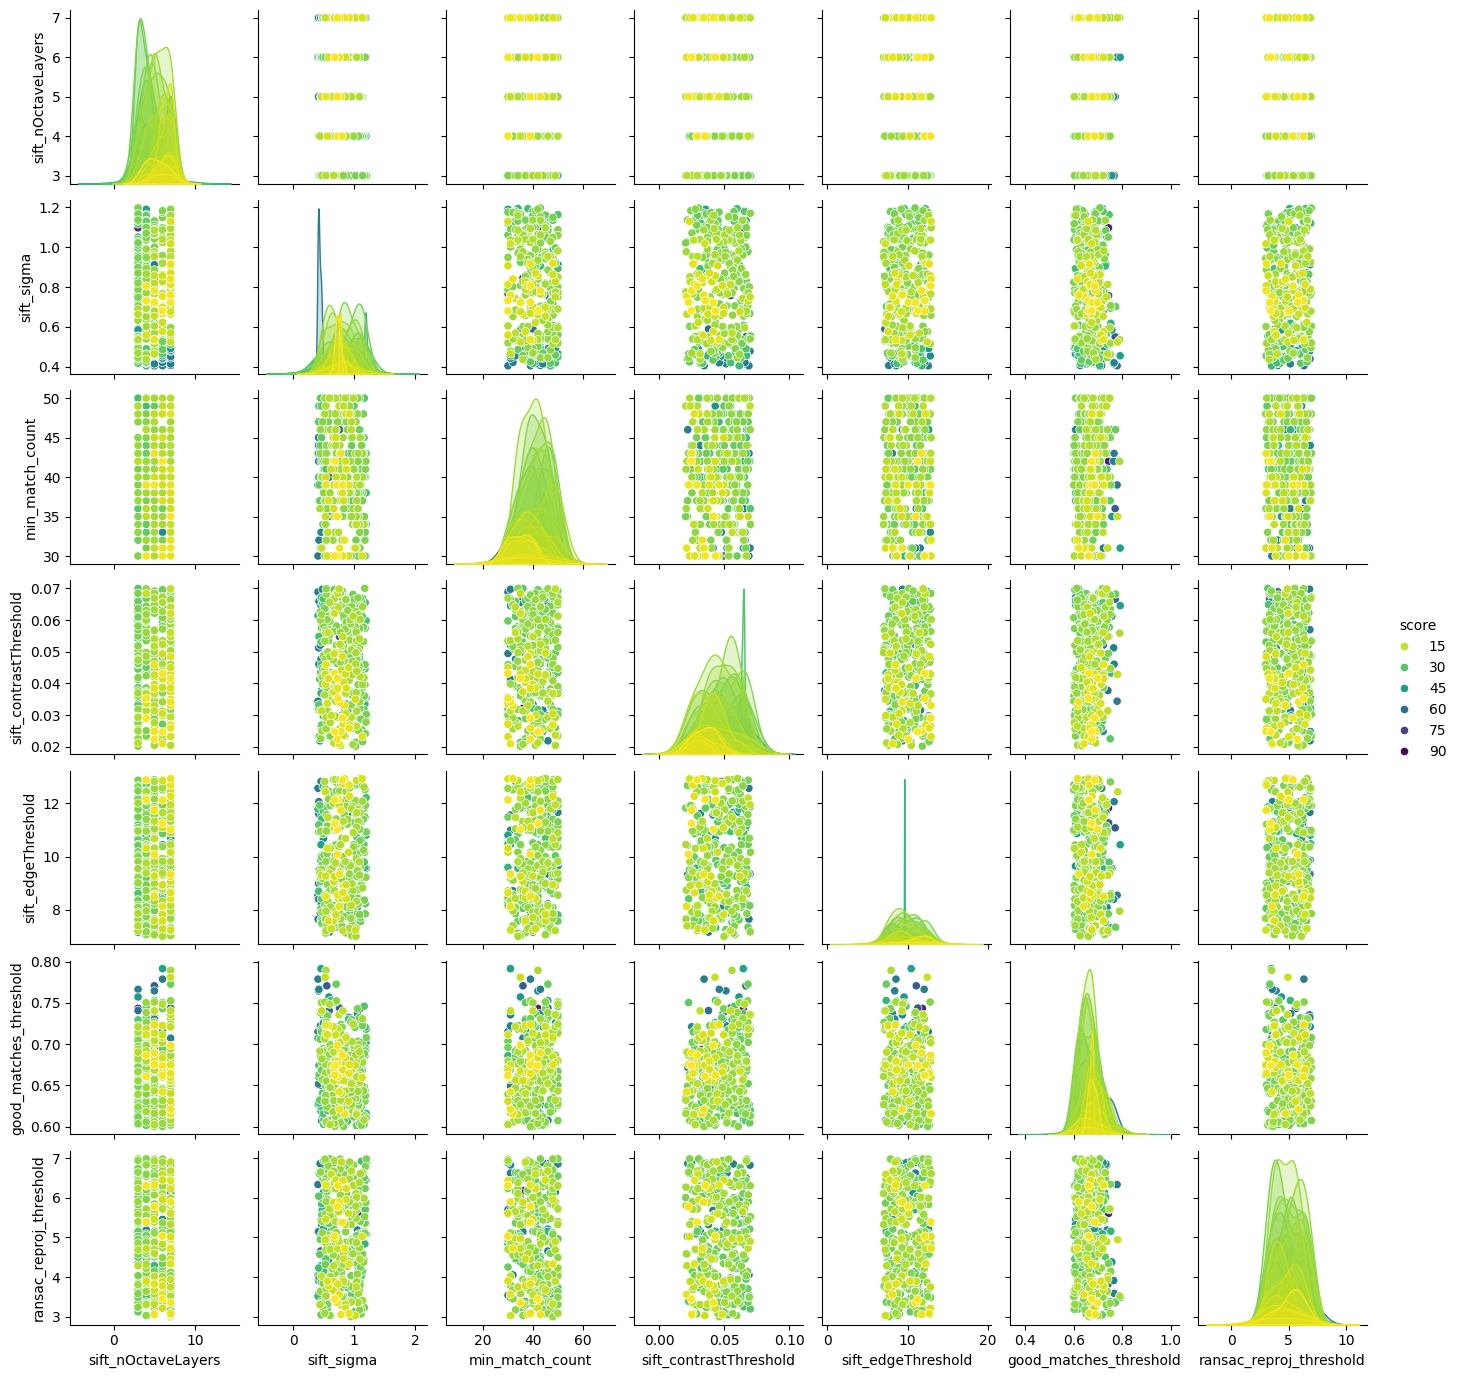

In [49]:
sns.pairplot(
    df[df[target] < 100],
    hue=target,
    palette='viridis_r',
    diag_kind='kde',
    height=2,
    aspect=1
);

From this graph, no clear relationship or trend emerges between individual parameters, parameter pairs, and the score. Nevertheless, some patterns can still be inferred.
The most evident one is that the parameter `good_matches_threshold` shows a relatively well-defined range where the model performs best (approximately 0.7 ± 0.05).

In general, the parameter ranges could be narrowed to focus the search around the most promising regions. Moreover, a weak trend appears between `nOctaveLayers` and `sigma`, suggesting that increasing both parameters further might lead to performance improvements worth exploring.

Since the features in the images are relatively small and detailed, it makes sense that reducing sigma (from its default value) and increasing nOctaveLayers leads to better results.
A lower sigma reduces the amount of Gaussian smoothing applied in the scale-space, allowing the detector to better preserve and capture fine details rather than merging them into coarser structures.
At the same time, increasing the number of octave layers provides denser sampling of scales, giving SIFT more opportunities to detect keypoints at slightly different resolutions — which is particularly beneficial when the objects of interest contain fine textures or small distinctive patterns.
Together, these effects improve the keypoint coverage on small-scale features, increasing the number of meaningful matches and consequently the overall detection performance.


## Grid search
Same as `random_search` function but here you do an exhaustive search on the neighbour of the best result

In [75]:
# Grid search
def grid_search(param_grid):
    """Grid search for hyperparameter optimization"""

    results = []

    # Create all combinations of hyperparameters
    keys, values = zip(*param_grid.items())
    param_combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

    print(f'Total combinations: {len(param_combinations)}', flush=True)

    try:
        for i, hyperparameters in enumerate(param_combinations):

            # Evaluate current hyperparameters
            score = evaluate(imgs_scene_paths, imgs_model_paths, hyperparameters)

            print(f'Grid eval {i+1}/{len(param_combinations)}: score={score}, hyperparameters={hyperparameters}', flush=True)

            # Flatten hyperparameters into separate columns
            result_row = {'score': score, 'iteration': i}
            result_row.update(hyperparameters)
            results.append(result_row)
    except KeyboardInterrupt:
        print("Grid search interrupted", flush=True)

    # Create DataFrame from results
    df_results = pd.DataFrame(results)
    # Sort with best score on top
    df_results.sort_values('score', ascending=False, inplace=True)
    df_results.reset_index(drop=True, inplace=True)
    return df_results

> :warning: **Warning:** DO NOT RUN THIS CELL

In [36]:
# Param grid
param_grid = {
  'sift_nOctaveLayers': [7, 8, 9],
  'sift_sigma': [0.8, 0.9, 1.0],
  'min_match_count': [35, 40, 45],
  'sift_contrastThreshold': [0.04],
  'sift_edgeThreshold': [9, 10, 11],
  'good_matches_threshold': [0.7],
  'ransac_reproj_threshold': [3.5, 4.0, 4.5, 5.0]                            
}

out_dir = 'results'
os.makedirs(out_dir, exist_ok=True)

print("Starting Grid Search", flush=True)
out_file = f'grid_search_{time()}.csv'

grid_search_results = grid_search(param_grid)

# save grid_search_results to csv
grid_search_results.to_csv(os.path.join(out_dir, out_file), index=False)

Starting Grid Search
Total combinations: 324
Grid eval 1/324: score=7, hyperparameters={'sift_nOctaveLayers': 7, 'sift_sigma': 0.8, 'min_match_count': 35, 'sift_contrastThreshold': 0.04, 'sift_edgeThreshold': 9, 'good_matches_threshold': 0.7, 'ransac_reproj_threshold': 3.5}
Grid eval 2/324: score=10, hyperparameters={'sift_nOctaveLayers': 7, 'sift_sigma': 0.8, 'min_match_count': 35, 'sift_contrastThreshold': 0.04, 'sift_edgeThreshold': 9, 'good_matches_threshold': 0.7, 'ransac_reproj_threshold': 4.0}
Grid eval 3/324: score=7, hyperparameters={'sift_nOctaveLayers': 7, 'sift_sigma': 0.8, 'min_match_count': 35, 'sift_contrastThreshold': 0.04, 'sift_edgeThreshold': 9, 'good_matches_threshold': 0.7, 'ransac_reproj_threshold': 4.5}
Grid eval 4/324: score=11, hyperparameters={'sift_nOctaveLayers': 7, 'sift_sigma': 0.8, 'min_match_count': 35, 'sift_contrastThreshold': 0.04, 'sift_edgeThreshold': 9, 'good_matches_threshold': 0.7, 'ransac_reproj_threshold': 5.0}
Grid eval 5/324: score=6, hyperpa


# Final results
Based on the results obtained by the grid search we can now run the algorithm with the best found hyperparameters. The detection is not perfect, but it can well approximate the ground truth.

{'sift_nOctaveLayers': 8, 'sift_sigma': 0.9, 'sift_contrastThreshold': 0.04, 'sift_edgeThreshold': 10, 'min_match_count': 44, 'good_matches_threshold': 0.7, 'ransac_reproj_threshold': 4.0}

Scene 25:
Scene 19:
	Book 7 - 2 instance(s) found:
		Instance 1 {'top_left': (497, 40), 'top_right': (533, 40), 'bottom_left': (497, 587), 'bottom_right': (533, 587), 'area': 19688}
		Instance 2 {'top_left': (458, 44), 'top_right': (494, 41), 'bottom_left': (459, 581), 'bottom_right': (495, 584), 'area': 19415}
	Book 6 - 3 instance(s) found:
		Instance 1 {'top_left': (385, 32), 'top_right': (410, 31), 'bottom_left': (385, 579), 'bottom_right': (411, 579), 'area': 14178}
		Instance 2 {'top_left': (411, 26), 'top_right': (437, 32), 'bottom_left': (409, 581), 'bottom_right': (435, 575), 'area': 14013}
		Instance 3 {'top_left': (439, 26), 'top_right': (464, 26), 'bottom_left': (437, 577), 'bottom_right': (463, 578), 'area': 14073}


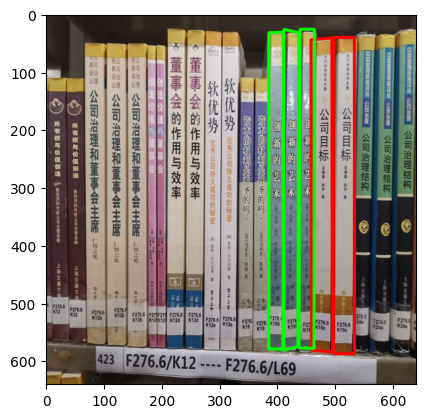

Scene 9:
	Book 19 - 4 instance(s) found:
		Instance 1 {'top_left': (436, 328), 'top_right': (439, 355), 'bottom_left': (137, 338), 'bottom_right': (138, 366), 'area': 8266}
		Instance 2 {'top_left': (438, 305), 'top_right': (438, 329), 'bottom_left': (135, 313), 'bottom_right': (135, 338), 'area': 7476}
		Instance 3 {'top_left': (437, 356), 'top_right': (443, 384), 'bottom_left': (153, 367), 'bottom_right': (127, 395), 'area': 8251}
		Instance 4 {'top_left': (446, 382), 'top_right': (440, 408), 'bottom_left': (135, 393), 'bottom_right': (147, 419), 'area': 7949}


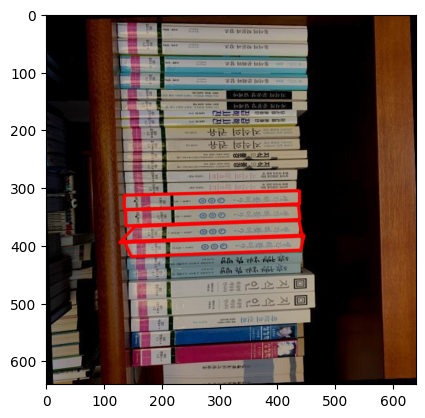

Scene 7:
	Book 20 - 2 instance(s) found:
		Instance 1 {'top_left': (236, 173), 'top_right': (289, 173), 'bottom_left': (236, 555), 'bottom_right': (289, 555), 'area': 20396}
		Instance 2 {'top_left': (279, 171), 'top_right': (334, 170), 'bottom_left': (276, 560), 'bottom_right': (330, 562), 'area': 21419}


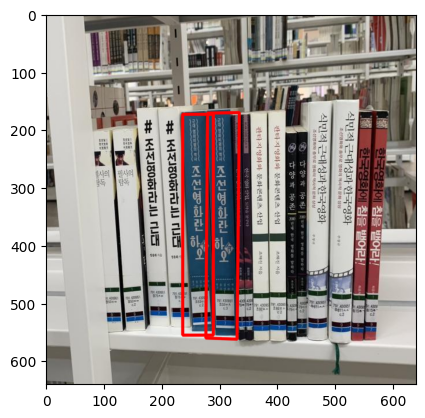

Scene 22:
Scene 15:
	Book 11 - 2 instance(s) found:
		Instance 1 {'top_left': (257, 186), 'top_right': (298, 188), 'bottom_left': (251, 534), 'bottom_right': (292, 535), 'area': 14220}
		Instance 2 {'top_left': (219, 189), 'top_right': (264, 164), 'bottom_left': (221, 449), 'bottom_right': (252, 495), 'area': 11168}
	Book 12 - 3 instance(s) found:
		Instance 1 {'top_left': (499, 214), 'top_right': (529, 215), 'bottom_left': (494, 527), 'bottom_right': (523, 527), 'area': 9102}
		Instance 2 {'top_left': (525, 215), 'top_right': (554, 214), 'bottom_left': (518, 522), 'bottom_right': (547, 526), 'area': 9111}
		Instance 3 {'top_left': (473, 211), 'top_right': (504, 214), 'bottom_left': (467, 533), 'bottom_right': (498, 524), 'area': 9832}


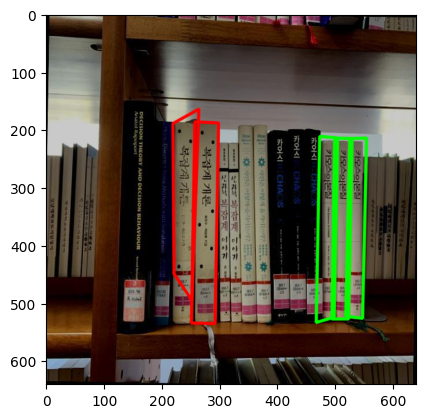

Scene 24:
Scene 27:
	Book 3 - 2 instance(s) found:
		Instance 1 {'top_left': (416, 142), 'top_right': (466, 142), 'bottom_left': (400, 566), 'bottom_right': (448, 566), 'area': 20774}
		Instance 2 {'top_left': (360, 83), 'top_right': (423, 80), 'bottom_left': (352, 578), 'bottom_right': (402, 576), 'area': 27894}
	Book 2 - 3 instance(s) found:
		Instance 1 {'top_left': (257, 146), 'top_right': (302, 146), 'bottom_left': (257, 563), 'bottom_right': (302, 563), 'area': 18642}
		Instance 2 {'top_left': (309, 152), 'top_right': (362, 136), 'bottom_left': (298, 581), 'bottom_right': (355, 591), 'area': 24100}
		Instance 3 {'top_left': (525, 163), 'top_right': (570, 161), 'bottom_left': (493, 557), 'bottom_right': (547, 557), 'area': 19231}


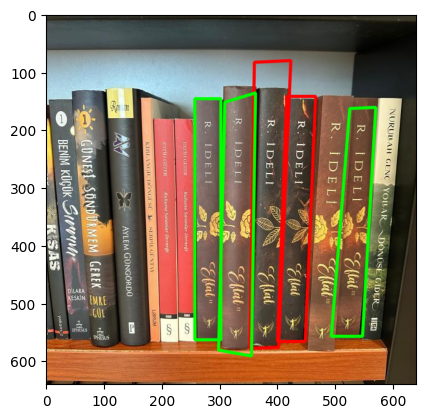

Scene 8:
Scene 3:
	Book 16 - 2 instance(s) found:
		Instance 1 {'top_left': (377, 209), 'top_right': (425, 209), 'bottom_left': (377, 542), 'bottom_right': (425, 542), 'area': 16050}
		Instance 2 {'top_left': (425, 210), 'top_right': (474, 209), 'bottom_left': (418, 549), 'bottom_right': (466, 548), 'area': 16453}


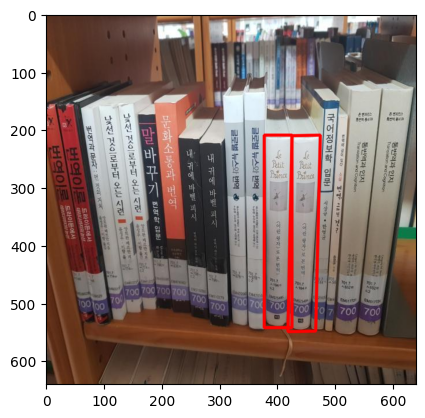

Scene 28:
	Book 1 - 2 instance(s) found:
		Instance 1 {'top_left': (206, 247), 'top_right': (235, 247), 'bottom_left': (206, 554), 'bottom_right': (235, 554), 'area': 8738}
		Instance 2 {'top_left': (237, 248), 'top_right': (265, 243), 'bottom_left': (236, 549), 'bottom_right': (265, 551), 'area': 8648}


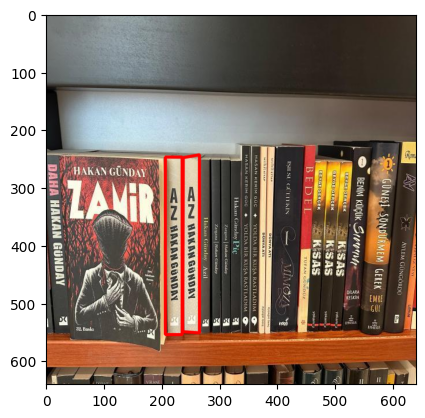

Scene 1:
	Book 18 - 2 instance(s) found:
		Instance 1 {'top_left': (441, 42), 'top_right': (490, 42), 'bottom_left': (441, 520), 'bottom_right': (490, 520), 'area': 23353}
		Instance 2 {'top_left': (489, 39), 'top_right': (536, 40), 'bottom_left': (482, 515), 'bottom_right': (530, 516), 'area': 22469}


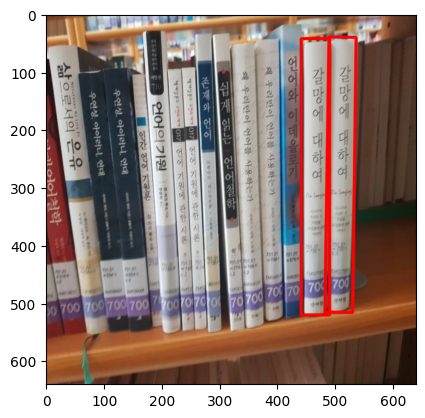

Scene 17:
	Book 11 - 2 instance(s) found:
		Instance 1 {'top_left': (254, 187), 'top_right': (295, 187), 'bottom_left': (254, 535), 'bottom_right': (295, 535), 'area': 14259}
		Instance 2 {'top_left': (215, 183), 'top_right': (257, 188), 'bottom_left': (210, 542), 'bottom_right': (252, 529), 'area': 14773}
	Book 12 - 3 instance(s) found:
		Instance 1 {'top_left': (497, 211), 'top_right': (526, 211), 'bottom_left': (497, 523), 'bottom_right': (526, 523), 'area': 9055}
		Instance 2 {'top_left': (523, 211), 'top_right': (551, 211), 'bottom_left': (522, 526), 'bottom_right': (550, 528), 'area': 9044}
		Instance 3 {'top_left': (471, 210), 'top_right': (501, 207), 'bottom_left': (472, 514), 'bottom_right': (502, 520), 'area': 9115}


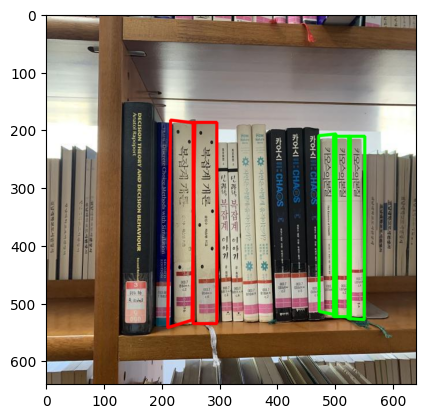

Scene 14:
Scene 5:
	Book 13 - 1 instance(s) found:
		Instance 1 {'top_left': (102, 69), 'top_right': (145, 69), 'bottom_left': (102, 572), 'bottom_right': (145, 572), 'area': 21643}


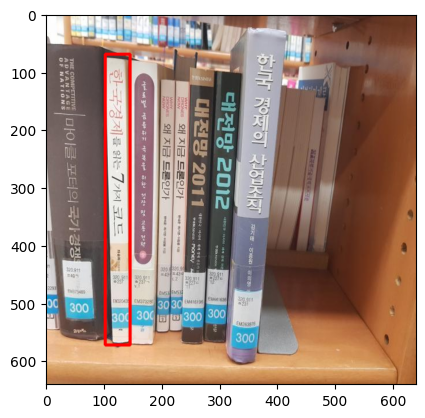

Scene 2:
	Book 17 - 1 instance(s) found:
		Instance 1 {'top_left': (283, 25), 'top_right': (318, 25), 'bottom_left': (283, 503), 'bottom_right': (318, 503), 'area': 16404}


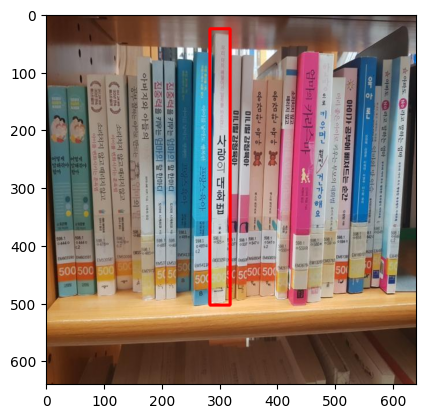

Scene 11:
Scene 16:
	Book 11 - 2 instance(s) found:
		Instance 1 {'top_left': (257, 186), 'top_right': (298, 188), 'bottom_left': (251, 534), 'bottom_right': (292, 535), 'area': 14224}
		Instance 2 {'top_left': (219, 189), 'top_right': (265, 164), 'bottom_left': (221, 449), 'bottom_right': (252, 494), 'area': 11200}
	Book 12 - 3 instance(s) found:
		Instance 1 {'top_left': (499, 214), 'top_right': (529, 215), 'bottom_left': (494, 527), 'bottom_right': (523, 527), 'area': 9111}
		Instance 2 {'top_left': (525, 215), 'top_right': (554, 214), 'bottom_left': (518, 518), 'bottom_right': (547, 527), 'area': 9031}
		Instance 3 {'top_left': (473, 212), 'top_right': (503, 214), 'bottom_left': (467, 540), 'bottom_right': (498, 536), 'area': 9889}


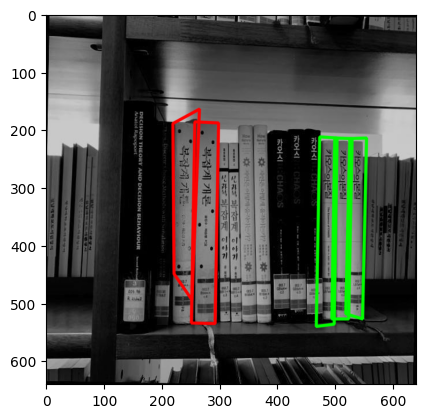

Scene 0:
Scene 4:
	Book 15 - 2 instance(s) found:
		Instance 1 {'top_left': (226, 48), 'top_right': (267, 48), 'bottom_left': (226, 608), 'bottom_right': (267, 608), 'area': 22964}
		Instance 2 {'top_left': (191, 43), 'top_right': (234, 44), 'bottom_left': (197, 607), 'bottom_right': (238, 606), 'area': 23550}
	Book 14 - 2 instance(s) found:
		Instance 1 {'top_left': (92, 1), 'top_right': (135, 1), 'bottom_left': (92, 617), 'bottom_right': (135, 617), 'area': 26500}
		Instance 2 {'top_left': (55, -2), 'top_right': (98, -3), 'bottom_left': (60, 617), 'bottom_right': (102, 620), 'area': 26561}


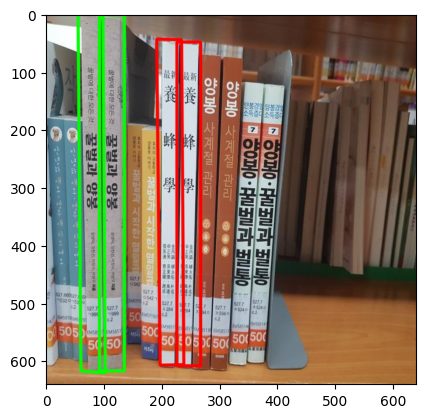

Scene 21:
Scene 13:
Scene 12:
Scene 6:
	Book 21 - 1 instance(s) found:
		Instance 1 {'top_left': (217, 73), 'top_right': (270, 73), 'bottom_left': (217, 563), 'bottom_right': (270, 563), 'area': 26120}


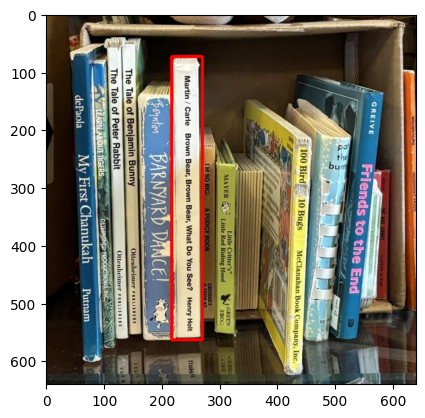

Scene 23:
	Book 5 - 1 instance(s) found:
		Instance 1 {'top_left': (342, 149), 'top_right': (391, 149), 'bottom_left': (342, 571), 'bottom_right': (391, 571), 'area': 20616}


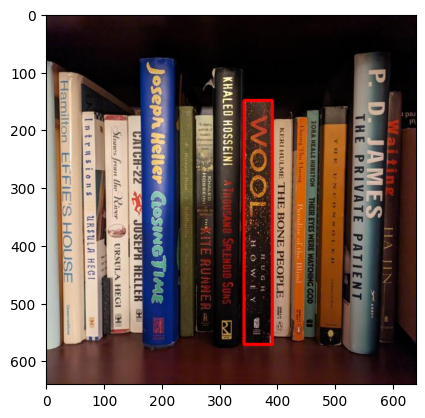

Scene 10:
	Book 19 - 4 instance(s) found:
		Instance 1 {'top_left': (332, 203), 'top_right': (359, 203), 'bottom_left': (332, 503), 'bottom_right': (359, 503), 'area': 8248}
		Instance 2 {'top_left': (307, 203), 'top_right': (335, 203), 'bottom_left': (304, 504), 'bottom_right': (332, 507), 'area': 8420}
		Instance 3 {'top_left': (359, 196), 'top_right': (386, 204), 'bottom_left': (360, 498), 'bottom_right': (384, 472), 'area': 7204}
		Instance 4 {'top_left': (386, 199), 'top_right': (413, 201), 'bottom_left': (386, 503), 'bottom_right': (412, 503), 'area': 8020}


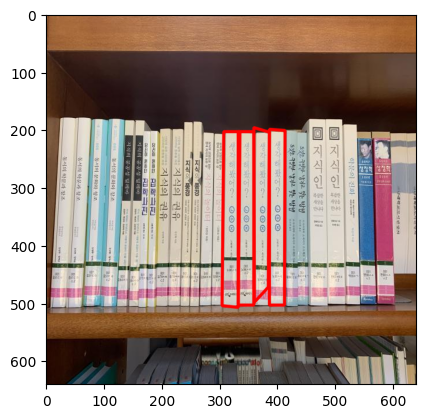

Scene 20:
Scene 26:
	Book 0 - 2 instance(s) found:
		Instance 1 {'top_left': (210, 180), 'top_right': (243, 180), 'bottom_left': (210, 567), 'bottom_right': (243, 567), 'area': 13007}
		Instance 2 {'top_left': (169, 181), 'top_right': (203, 180), 'bottom_left': (176, 570), 'bottom_right': (209, 570), 'area': 13121}
	Book 4 - 1 instance(s) found:
		Instance 1 {'top_left': (248, 183), 'top_right': (432, 183), 'bottom_left': (248, 526), 'bottom_right': (432, 526), 'area': 63062}


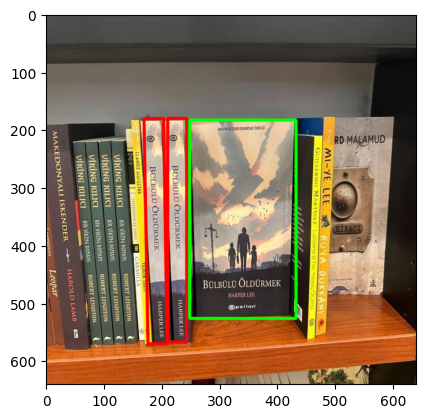

Scene 18:
	Book 10 - 3 instance(s) found:
		Instance 1 {'top_left': (108, 38), 'top_right': (135, 38), 'bottom_left': (108, 584), 'bottom_right': (135, 584), 'area': 14754}
		Instance 2 {'top_left': (139, 44), 'top_right': (166, 37), 'bottom_left': (138, 577), 'bottom_right': (165, 588), 'area': 14482}
		Instance 3 {'top_left': (77, 37), 'top_right': (103, 42), 'bottom_left': (79, 589), 'bottom_right': (106, 584), 'area': 14341}
	Book 9 - 3 instance(s) found:
		Instance 1 {'top_left': (315, 130), 'top_right': (342, 130), 'bottom_left': (315, 586), 'bottom_right': (342, 586), 'area': 12227}
		Instance 2 {'top_left': (291, 128), 'top_right': (318, 128), 'bottom_left': (289, 585), 'bottom_right': (316, 585), 'area': 12411}
		Instance 3 {'top_left': (267, 124), 'top_right': (294, 126), 'bottom_left': (262, 583), 'bottom_right': (289, 583), 'area': 12388}
	Book 8 - 0 instance(s) found:


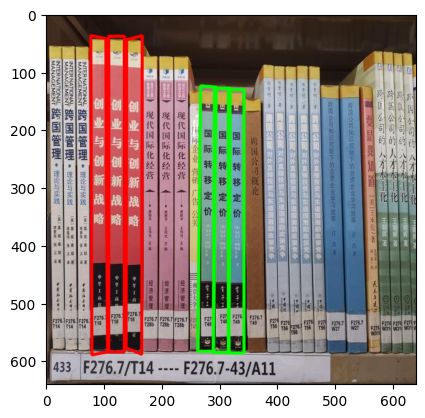

In [98]:
# Hyper-parameters
best_known_params = {
    'sift_nOctaveLayers': 8,
    'sift_sigma': 0.9,
    'sift_contrastThreshold': 0.04,
    'sift_edgeThreshold': 10,
    'min_match_count': 44,
    'good_matches_threshold': 0.7,
    'ransac_reproj_threshold': 4.0,
}

# Five common colors for plotting
colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0), (255, 0, 255)]

# Get models kp, des
kp_des_models = get_keypoints(imgs_model_paths, best_known_params)

print(best_known_params)
print()

# Scenes loop
for i, s in enumerate(imgs_scene_paths):
    
    # Extract scene index
    scene_index = s.split('_')[1].split('.')[0]
    print(f"Scene {scene_index}:")
    
    # Read scene image
    img_scene = cv2.imread(s)
    img_scene = cv2.cvtColor(img_scene, cv2.COLOR_BGR2RGB)

    # Get ground truth counts for the scene
    gt_counts = ground_truth[f'scene_{scene_index}']

    # Locate books in the scene
    books = find_books_in_scene(s, kp_des_models, best_known_params)

    color = -1

    # Loop on models found in the scene
    for model_key, instances in books.items():

        # Extract book index
        book_index = model_key.split('_')[1]

        # Get expected count from ground truth
        expected_count = gt_counts[int(book_index)]

        # Skip books with no instances and true
        if not instances and expected_count == 0:
            continue 

        color = (color + 1) % len(colors)

        # Print predicted result
        print(f"\tBook {book_index} - {len(instances)} instance(s) found:")

        for k, instance in enumerate(instances):

            # Create and fill the dictionary for printing
            printing_instance = {}
            printing_instance["top_left"] = instance["top_left"]
            printing_instance["top_right"] = instance["top_right"]
            printing_instance["bottom_left"] = instance["bottom_left"]
            printing_instance["bottom_right"] = instance["bottom_right"]
            printing_instance["area"] = instance["area"]

            print(f"\t\tInstance {k+1} {printing_instance}")

            # Draw the bounding box on the scene image
            img_scene = cv2.polylines(img_scene,[np.int32(instance["dst"])], True, colors[color], 3, cv2.LINE_AA)
        
        # Show the scene with all detected books
        plt.imshow(img_scene)
    
    # Plot the scene with the bounding boxes for all books
    plt.show()